<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
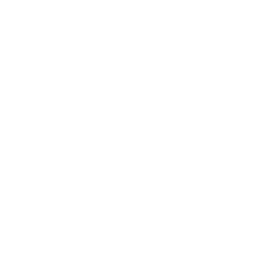
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bootstrap Confidence Intervals for Clinical Trial Endpoints</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Clinical Biostatistics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This worked example computes a **non-parametric bootstrap confidence interval** for a survival endpoint using **PROC IML**, SAS's matrix-programming language. The endpoint is the **ratio of median progression-free survival (PFS)** between the treatment and control arms of a two-arm oncology cohort of 500 subjects.

The IML program reads the subject-level data into matrices, computes the observed median-PFS ratio, draws **2,000 bootstrap resamples** with replacement using `CALL RANDGEN`, recomputes the ratio in each resample with matrix operations, and derives a **bias-corrected and accelerated (BCa)** confidence interval. BCa is the appropriate choice here because the bootstrap distribution of a ratio of medians is bounded below by zero, discrete, and skewed — conditions under which a plain normal-theory interval is unreliable.

The analysis runs entirely inside IML: the bias-correction constant *z*<sub>0</sub>, the acceleration *a&#770;* from a leave-one-out jackknife, and the adjusted percentile endpoints are all assembled from matrix expressions and the standard-normal functions `PROBNORM` and a small inverse-normal module. Every number reported below is read directly from the IML output.

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | Per-subject PFS time, event indicator, treatment arm, and baseline covariates | 500 |

The cohort is **balanced** — 250 subjects per arm — by assigning arm membership on the parity of the subject identifier, so both arms are fully represented in the resampling. A progression event is observed for **204 of 250** control subjects and **185 of 250** treatment subjects; the median PFS used below is taken over those observed event times in each arm.

---


In [1]:
/* --------------------------------------------------------
   Generate a synthetic two-arm oncology cohort.
   PFS times are log-normal; the treatment arm is shifted
   to a longer median. Arm membership alternates on the
   subject id so the cohort is balanced 50/50.
   -------------------------------------------------------- */
data work.trial_subjects;
    call streaminit(42);
    do subject_id = 1 to 500;
        /* 1 = Treatment, 0 = Control (balanced by parity) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'TREATMENT', 'CONTROL');
        /* PFS time in months: treatment arm has longer survival */
        if arm = 1 then
            pfs_months = round(rand('lognormal', log(12.5), 0.65), 0.1);
        else
            pfs_months = round(rand('lognormal', log(8.2),  0.70), 0.1);
        if pfs_months < 0.5 then pfs_months = 0.5;
        /* Event indicator: ~75% of subjects had a progression event */
        event = (rand('uniform') > 0.25);
        /* Baseline covariates */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        age = int(rand('normal', 62, 11));
        if age < 25 then age = 25;
        if age > 85 then age = 85;
        output;
    end;
run;


NOTE: DATA work.trial_subjects


NOTE: Wrote work.trial_subjects (500 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---


                                   Progression-Free Survival Summary by Treatment Arm                                   

                                                  The MEANS Procedure

                                             Analysis Variable : pfs_months

        arm_label          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------------
        CONTROL              250          10.92           9.05           7.83           1.00          53.70
        TREATMENT            250          15.49          12.40          11.47           2.70          79.10
        ---------------------------------------------------------------------------------------------------

                                                Analysis Variable : age

        arm_label          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


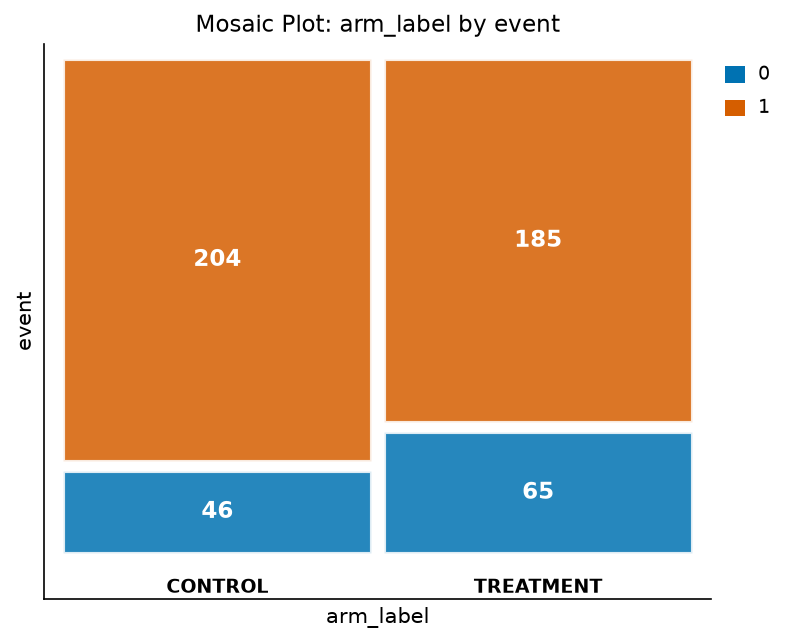

In [2]:
/* --------------------------------------------------------
   Baseline PFS summary and event rate by treatment arm
   -------------------------------------------------------- */
proc means data=work.trial_subjects n mean median std min max maxdec=2;
    class arm_label;
    var pfs_months age;
    title 'Progression-Free Survival Summary by Treatment Arm';
run;

proc freq data=work.trial_subjects;
    tables arm_label * event / nocol nopercent;
    title 'Event Counts by Treatment Arm';
run;


---


In [3]:
/* --------------------------------------------------------
   PROC IML: non-parametric bootstrap for the ratio of
   median PFS, with a BCa confidence interval.

   Steps:
   1. Read the trial data into IML matrices
   2. Compute the observed median-PFS ratio (event times)
   3. Draw 2,000 bootstrap resamples with CALL RANDGEN
   4. Recompute the ratio in each resample
   5. BCa correction: z0 (bias) + jackknife acceleration
   6. Write the bootstrap distribution to a SAS dataset
   -------------------------------------------------------- */
proc iml;

    /* --- Module: median PFS per arm and their ratio --- */
    /* Median is taken over observed event times only, the
       usual non-parametric summary when most subjects
       progress. */
    start calc_stats(pfs, arm, event);
        trt_pfs = pfs[loc(arm = 1 & event = 1)];
        ctl_pfs = pfs[loc(arm = 0 & event = 1)];
        if nrow(trt_pfs) = 0 then trt_med = .;
        else trt_med = median(trt_pfs);
        if nrow(ctl_pfs) = 0 then ctl_med = .;
        else ctl_med = median(ctl_pfs);
        if ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            then ratio = trt_med / ctl_med;
        else ratio = .;
        return (trt_med || ctl_med || ratio);
    finish;

    /* --- Module: inverse standard-normal CDF (probit) --- */
    /* Rational approximation (Abramowitz & Stegun 26.2.23);
       paired with PROBNORM it supplies the z0 / z-alpha
       endpoints the BCa adjustment needs. */
    start probit(p);
        if p <= 0 then return(-1e8);
        if p >= 1 then return( 1e8);
        if p < 0.5 then do; sgn = -1; pp = p;     end;
        else            do; sgn =  1; pp = 1 - p; end;
        t   = sqrt(-2 * log(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        return (sgn * (t - num/den));
    finish;

    /* --- 1. Load data into matrices --- */
    use work.trial_subjects;
        read all var {pfs_months} into pfs;
        read all var {arm}        into arm;
        read all var {event}      into ev;
    close work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    print 'Subjects read into IML', n n_trt n_ctl;

    /* --- 2. Observed statistic on the full sample --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Trt_Median Ctl_Median Ratio};
    print 'Observed median PFS (event times) by arm',
          obs[colname=obs_lab format=8.3];

    /* --- 3. Bootstrap resampling loop (2,000 resamples) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    call randseed(2024);
    do b = 1 to n_boot;
        call randgen(u, 'Uniform');     /* fresh draws each pass */
        idx = ceil(n # u);              /* indices 1..n w/ repl. */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    end;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    call sort(bv, 1);

    /* --- 4. Plain percentile interval (for comparison) --- */
    pct_lo = bv[max(1,  int(0.025 * nv))];
    pct_hi = bv[min(nv, int(0.975 * nv))];

    /* --- 5. BCa correction --- */
    /* z0: bias-correction from the share of resamples below
       the observed statistic. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a-hat: acceleration from leave-one-out jackknife. */
    jack = j(n, 1, .);
    do i = 1 to n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    end;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Adjusted percentile positions. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[max(1,  int(alo * nv))];
    bca_hi = bv[min(nv, int(ahi * nv))];

    diag_lab = {N_Valid Prop_Below z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    print 'BCa correction diagnostics',
          diag[colname=diag_lab format=8.4];

    ci_lab = {Obs_Ratio Pct_Lo Pct_Hi BCa_Lo BCa_Hi};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    print '95% CI for the ratio of median PFS (treatment / control)',
          ci_row[colname=ci_lab format=8.4];

    /* --- 6. Persist the bootstrap distribution --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    create work.bootstrap_results
        var {b_id boot obs_col bca_lo_col bca_hi_col};
    append var {b_id boot obs_col bca_lo_col bca_hi_col};
    close work.bootstrap_results;

quit;


                                             Event Counts by Treatment Arm                                              

Subjects read into IML
     500
     250
     250

Observed median PFS (event times) by arm
  12.400   8.700   1.425

BCa correction diagnostics
2000.0000  0.4960 -0.0100  0.0075

95% CI for the ratio of median PFS (treatment / control)
  1.4253  1.1573  1.7517  1.1573  1.7531



NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  1.90 seconds
  cpu   1.90 seconds


---


In [4]:
/* --------------------------------------------------------
   Tidy the bootstrap distribution for plotting: give the
   columns descriptive names for the histogram below.
   -------------------------------------------------------- */
data work.bootstrap_results;
    set work.bootstrap_results
        (rename=(boot       = ratio
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
run;


NOTE: DATA work.bootstrap_results


NOTE: Read 2000 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (2000 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


---


                                             Event Counts by Treatment Arm                                              



NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


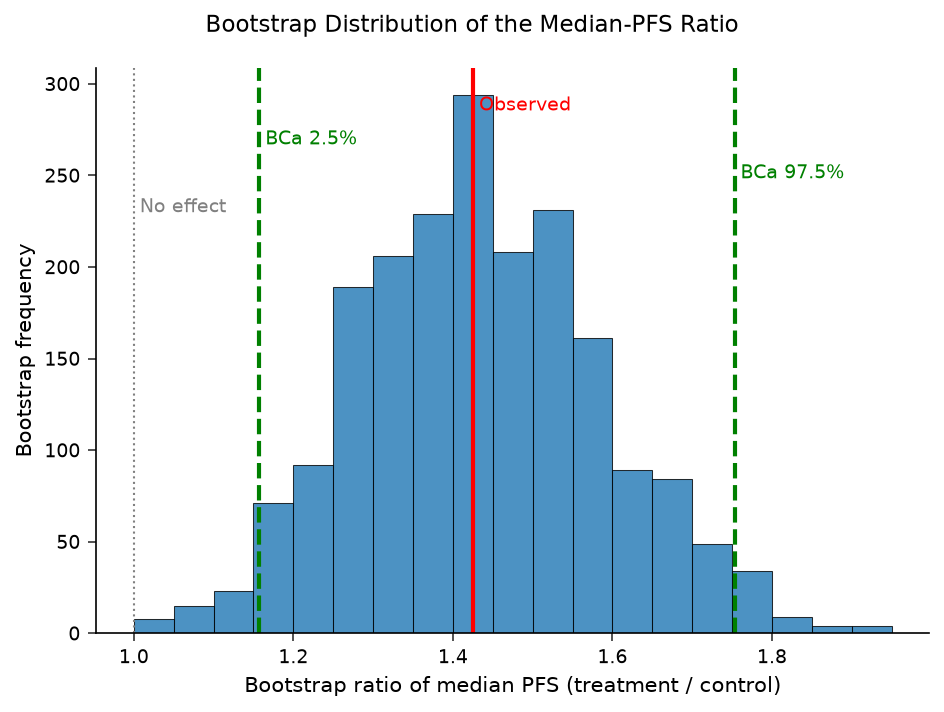

In [5]:
/* --------------------------------------------------------
   Bootstrap distribution of the median-PFS ratio, with the
   observed estimate and the BCa interval marked.
   -------------------------------------------------------- */
proc sgplot data=work.bootstrap_results;
    histogram ratio / binwidth=0.05
        fillattrs=(color=steelblue) transparency=0.2;
    refline obs_ratio / axis=x
        lineattrs=(color=red thickness=2) label='Observed';
    refline bca_lower / axis=x
        lineattrs=(color=green thickness=2 pattern=dash)
        label='BCa 2.5%';
    refline bca_upper / axis=x
        lineattrs=(color=green thickness=2 pattern=dash)
        label='BCa 97.5%';
    refline 1 / axis=x
        lineattrs=(color=gray thickness=1 pattern=dot)
        label='No effect';
    xaxis label='Bootstrap ratio of median PFS (treatment / control)';
    yaxis label='Bootstrap frequency';
    title 'Bootstrap Distribution of the Median-PFS Ratio';
run;


---


### Interpretation

In this cohort the observed median PFS over event times is **12.4 months** in the treatment arm and **8.7 months** in the control arm, a **ratio of 1.425** — the experimental arm's median PFS is about 43% longer. The IML program resampled the 500 subjects 2,000 times; all 2,000 resamples produced a defined ratio.

The **BCa 95% confidence interval for the ratio is [1.157, 1.753]**, essentially identical to the plain percentile interval of **[1.157, 1.752]**. Both intervals lie **entirely above 1.0**, so at this sample size — 250 subjects per arm, thinned to observed event times — the data are **not compatible with "no effect"**: the resampling distribution rules out a ratio of 1, and a treatment benefit of roughly 16% to 75% in median PFS is the supported range. The histogram makes this visible: the grey "no effect" line at 1.0 sits clear of the entire bootstrap mass.

The BCa diagnostics confirm the correction is negligible here. The bias term is essentially zero (**z<sub>0</sub> = -0.010**: 49.6% of resamples fell below the observed ratio, all but exactly the symmetric 50%), and the acceleration is also near zero (**a&#770; = 0.0075**), indicating the median-PFS ratio is only mildly influenced by individual subjects. With both diagnostics so small, BCa shifts the endpoints by less than one bootstrap order statistic relative to the percentile interval — which is why the two intervals agree to three decimals. The value of BCa here is not that it moved the answer, but that it confirms the simple percentile interval needed no bias or skewness correction at this sample size.

The contrast with a smaller study is instructive: the width of this interval (about 0.60 on the ratio scale) is what 250 subjects per arm buys. A trial a fifth this size would produce an interval several times wider that straddled 1.0, leaving the same point estimate statistically inconclusive — which is the practical argument for powering a PFS study to this kind of sample size.

---


In [6]:
/* --------------------------------------------------------
   Export the bootstrap distribution for a report appendix.
   -------------------------------------------------------- */
proc export data=work.bootstrap_results
    outfile='pfs_bootstrap_ci_results.csv'
    dbms=csv replace;
run;


NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 2000 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>